In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd


In [85]:

df_ncr = gpd.read_file("Raw_Data/delhi_ncr_region.geojson")

In [86]:
#cobert this data into utm
ncr_utm = df_ncr.to_crs(epsg=32644)

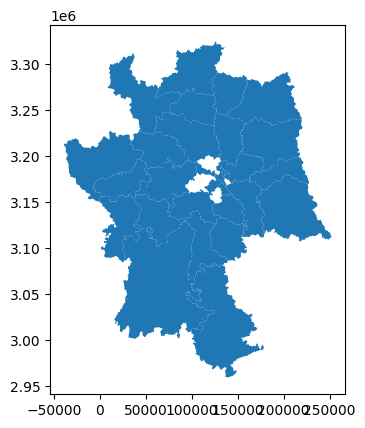

In [87]:
ncr_utm.plot()
plt.show()

In [88]:
print(ncr_utm.columns)

Index(['geometry'], dtype='object')


In [89]:
print(ncr_utm.dtypes)

geometry    geometry
dtype: object


In [90]:
ncr_utm.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  30 non-null     geometry
dtypes: geometry(1)
memory usage: 372.0 bytes


In [91]:
#check the missing value exist or not
ncr_utm.isnull().sum()

geometry    0
dtype: int64

plot a 60 * 60 grid


 Crd EPSG:32644
 Crs EPSG:32644


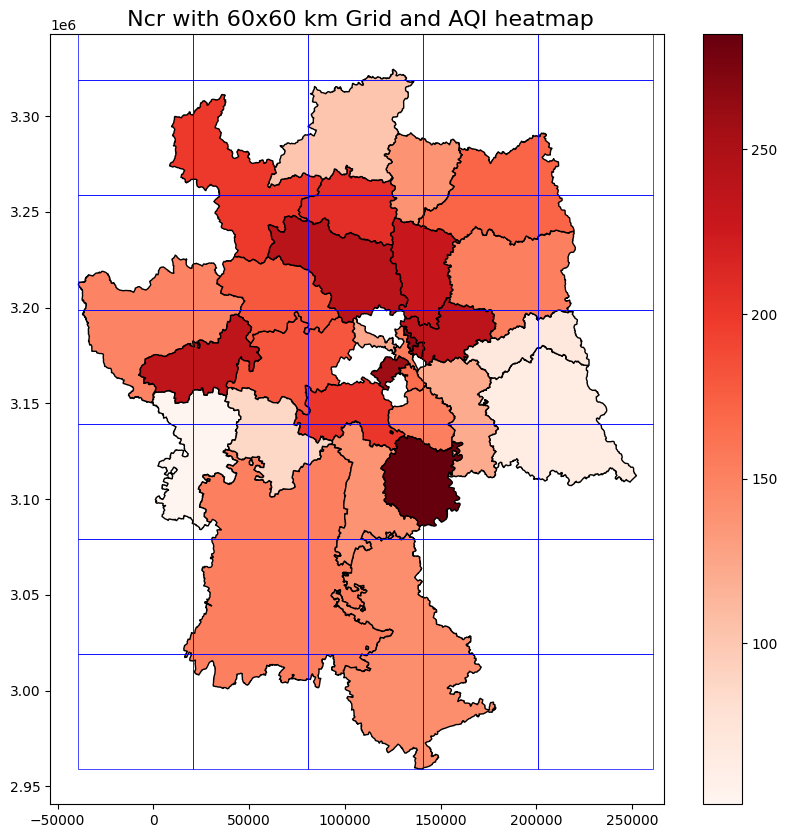

<Figure size 640x480 with 0 Axes>

In [99]:
print(" Crd", ncr_utm.crs)
ncr_utm = ncr_utm.to_crs(epsg=32644)
print(" Crs", ncr_utm.crs)
np.random.seed(42)
if 'AQI' not in ncr_utm.columns:
    ncr_utm['AQI'] = np.random.randint(50, 300, size=len(ncr_utm))

fig, ax = plt.subplots(figsize=(10,10))

ncr_utm.plot(column='AQI', ax=ax, cmap='Reds', edgecolor='black', legend=True)

xmin, ymin, xmax, ymax = ncr_utm.total_bounds
grid_size = 60000  #  for 60 km

# make grid on heatmap
for x in np.arange(xmin, xmax, grid_size):
    for y in np.arange(ymin, ymax, grid_size):
        rect = plt.Rectangle((x, y), grid_size, grid_size,
                             fill=False, edgecolor='blue', linewidth=0.5)
        ax.add_patch(rect)

plt.title(" Ncr with 60x60 km Grid and AQI heatmap", fontsize=16)


plt.show()
plt.savefig("Output/grid_plot.png")

load Satellite Images

In [108]:
import os , glob
from shapely.geometry import Point

image_folder = "Raw_Data/rgb"
image_paths = glob.glob(os.path.join(image_folder, "*.png"))

print("Total images Before filter", len(image_paths))

from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32644", always_xy=True)
filtered_images = [] # array for store the filtering images

for path in image_paths:
    filename = os.path.basename(path)
    parts = filename.replace(".png","").split("_")

    try:
        lat = float(parts[-2])
        lon = float(parts[-1])
    except:
        continue

    x, y = transformer.transform(lon, lat)
    point = Point(x, y)

    if ncr_utm.contains(point).any():
        filtered_images.append(path)

print("Total images after filter", len(filtered_images))





Total images Before filter 9216
Total images after filter 8015
